In [17]:
# laden der Packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import binom
from scipy.stats import hypergeom

In [18]:
import warnings
warnings.filterwarnings("ignore")

# Erwartungswert von Zufallsvariablen & Diskrete Verteilungen


### Ziele der Übung

- Zufallsvariablen und dessen Erwartungswerte
- Verteilungen pdf und cdf
- Diskrete Verteilungen: Hypergeometrische und Binomial Verteilung

**Hilfestellung:**
- Informationen zur Hypergeometrischen Verteilung in Python: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.hypergeom.html
-  Informationen zur Binomial Verteilung in Python: 
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html

## Aufgabe 1

Auf dem Martinimarkt entdeckst du folgendes Glücksspiel. Für einen Einsatz von 3 Euro kann der Spieler einmal mit zwei Würfel würfeln. Bei der Augensumme 11 und 12 erhält der Spieler jeweils 15 Euro und bei der Augensumme 2 erhält der Spieler 10 Euro. In allen anderen Fällen ist der Einsatz verloren. Macht der Spieler langfristig einen Gewinn?

In [19]:
E_G = (7*1/36)-3*2/36-3*3/36-3*4/36-3*5/36-3*6/36-3*5/36-3*4/36-3*3/36+12*2/36+12*1/36

print(E_G)
print("Verlust pro Spiel")

-1.4722222222222225
Verlust pro Spiel


In [20]:
#Produktion können pro tag mit wahrschienlichkeit auftreten
#0 -> 0.6, 1 -> 0.12, 2 -> 0.2, 3 -> 0.08
#Kosten für die behebung kann dadurch berechnet werden K(x) = 6 - ((6)/1+x)
#Was sind die zu erwartenden Kosten pro Tag

def Kosten(x):
    result = 6 - ((6)/(1+x))
    return result

E_Kosten = Kosten(0)*0.6 + Kosten(1)*0.12 + Kosten(2)*0.2 + Kosten(3)*0.08
print("Erwartete Kosten pro Tag: (in tsd Euro)",E_Kosten)

Erwartete Kosten pro Tag: (in tsd Euro) 1.52


In [21]:
#Chance im lotto zu gewinnen
from scipy.special import factorial

n = 49
k = 6

B = factorial(49)/(factorial(6)*factorial(49-6))
print(B)
print("Wahrscheinlichkeit richtig zu sein in Prozent:",(1/B)*100)

13983816.000000112
Wahrscheinlichkeit richtig zu sein in Prozent: 7.151123842018459e-06


In [24]:


A = factorial(4)/(factorial(0)*factorial(4-0))
B = factorial(5)/(factorial(4)*factorial(5-4))
C = factorial(9)/(factorial(4)*factorial(9-4))
P = ((A*B)/C)*100
print(P)



Erwartungswert = 0*0.0396+1*0.3175+2*0.4762+3*0.1587+4*0.0079
print(Erwartungswert)

3.968253968253968
1.7776


## Aufgabe 2

Eine Lieferung von 100 Geräten enthält typischerweise 5 defekte. Es werden für die Qualitätskontrolle drei Geräte entnommen.

a) Gib die Wahrscheinlichkeitsverteilung der Zufallsvariablen $X = $ *Anzahl der defekten Geräte in der Stichprobe* an. 

b) Stelle die Wahrscheinlichkeitsverteilung und kumulative Verteilungsfunktion graphisch dar. 

c) Wie groß ist die Wahrscheinlichkeit in dieser Stichprobe 
- kein defektes Gerät,
- höchstens ein defektes Gerät,
- mehr als ein defektes Gerät vorzufinden?

d) Mit wieviel defekten Geräten ist zu rechnen? 

e) Mit wieviel funktionstüchtigen Geräten ist zu rechnen?

[8.55998763e-01 1.38064317e-01 5.87507730e-03 6.18429190e-05]
[0.85599876 0.99406308 0.99993816 1.        ]


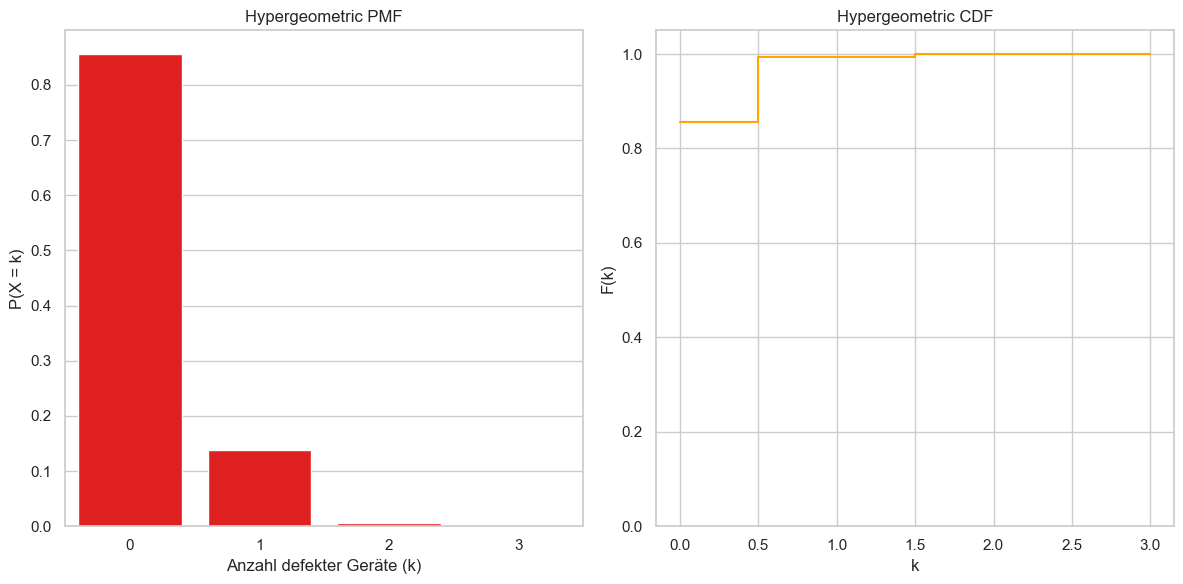

Erwartungswert funktionsfähig: 2.85
Erwartungswert defekt 0.15


In [29]:
N = 100 #100 Geräte
M = 5 #5 defekte Geräte
n = 3 # Stichprobe
k = np.arange(0, n+1)

pmf= hypergeom.pmf(k,N,M,n)
cdf= hypergeom.cdf(k,N,M,n)

print(pmf)
print(cdf)



df_pmf = pd.DataFrame({"k": k, "pmf": pmf})
df_cdf = pd.DataFrame({"k": k, "cdf": cdf})

# Plot-Stil
sns.set(style="whitegrid")

# Figure mit zwei Subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ----- PMF -----
sns.barplot(data=df_pmf, x="k", y="pmf", ax=axes[0],color="red")
axes[0].set_title("Hypergeometric PMF")
axes[0].set_xlabel("Anzahl defekter Geräte (k)")
axes[0].set_ylabel("P(X = k)")

# ----- CDF -----
sns.lineplot(data=df_cdf, x="k", y="cdf", ax=axes[1],drawstyle="steps-mid",color="orange")
axes[1].set_title("Hypergeometric CDF")
axes[1].set_xlabel("k")
axes[1].set_ylabel("F(k)")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()



G_ErwarteteDefekte = n*M/N
G_Erwartetefunktionsfähig = n - G_ErwarteteDefekte

print("Erwartungswert funktionsfähig:", G_Erwartetefunktionsfähig)
print("Erwartungswert defekt", G_ErwarteteDefekte)

Wahrscheinlichkeit für kein defektes Gerät: 85,56%

Wahrscheinlichkeit für ein defekt Gerät: 13.81%

Wahrscheinlichkeit für mehr als 1 defektes Gerät: 0.59%

## Aufgabe 3

Approximiere die Ergebnisse aus Aufgabe 2 mit der Binomialverteilung. Vergleiche die Ergebnisse. 

Eine Lieferung von 100 Geräten enthält typischerweise fünf defekte. Es werden für die Qualitätskontrolle drei Geräte entnommen.

aa) Darf ich approximieren?

a) Gib die Wahrscheinlichkeitsverteilung der Zufallsvariablen $X = $ *Anzahl der defekten Geräte in der Stichprobe* an. 

b) Stelle die Wahrscheinlichkeitsverteilung und kumulative Verteilungsfunktion graphisch dar. 

c) Wie groß ist die Wahrscheinlichkeit in dieser Stichprobe 
- kein defektes Gerät,
- höchstens ein defektes Gerät,
- mehr als ein defektes Gerät vorzufinden?

d) Mit wieviel defekten Geräten ist zu rechnen? 

e) Mit wieviel funktionstüchtigen Geräten ist zu rechnen?

f) Vergleiche die Ergebnisse mit den exakten Ergebnissen.

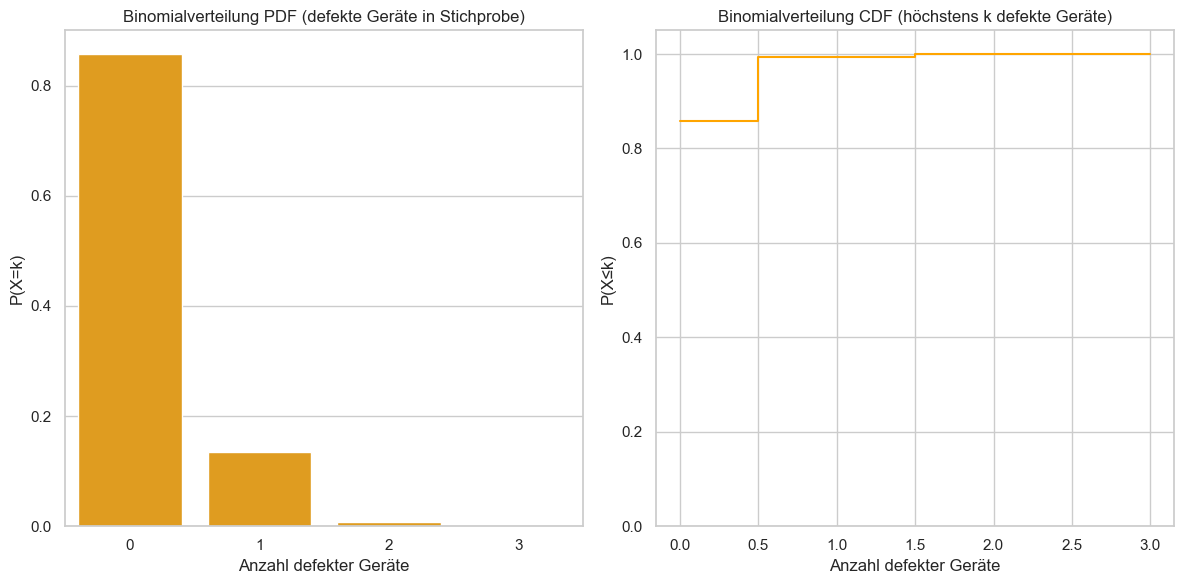

PDF: [8.57375e-01 1.35375e-01 7.12500e-03 1.25000e-04]
CDF: [0.857375 0.99275  0.999875 1.      ]
Erwartungswert Defekt 0.15000000000000002
Erwartungswert Funktionsfähig 2.85
Geometrisch-Binomial_Defekt -2.7755575615628914e-17
Geometrisch-Binomial_Funktionsf 0.0


In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameter für Stichprobe
n = 3        # Anzahl entnommener Geräte
p = 5/100    # Wahrscheinlichkeit für ein defektes Gerät
k = np.arange(0, n+1)  # mögliche Anzahl defekter Geräte

# PDF: Wahrscheinlichkeit genau k defekter Geräte
pdf = binom.pmf(k, n, p)

# CDF: Wahrscheinlichkeit höchstens k defekter Geräte
cdf = binom.cdf(k, n, p)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))

# PDF
plt.subplot(1,2,1)
sns.barplot(x=k, y=pdf, color="orange")
plt.title("Binomialverteilung PDF (defekte Geräte in Stichprobe)")
plt.xlabel("Anzahl defekter Geräte")
plt.ylabel("P(X=k)")

# CDF
plt.subplot(1,2,2)
sns.lineplot(x=k, y=cdf, color="orange",drawstyle="steps-mid")
plt.title("Binomialverteilung CDF (höchstens k defekte Geräte)")
plt.xlabel("Anzahl defekter Geräte")
plt.ylabel("P(X≤k)")
plt.ylim(0,1.05)

plt.tight_layout()
plt.show()

# Wahrscheinlichkeitswerte ausgeben
print("PDF:", pdf)
print("CDF:", cdf)



B_ErwarungswertDefekt = n*p

B_ErwaruntswertFunktionsfähig=3-B_ErwarungswertDefekt

print("Erwartungswert Defekt",B_ErwarungswertDefekt)
print("Erwartungswert Funktionsfähig",B_ErwaruntswertFunktionsfähig)

print("Geometrisch-Binomial_Defekt",G_ErwarteteDefekte-B_ErwarungswertDefekt)
print("Geometrisch-Binomial_Funktionsf",G_Erwartetefunktionsfähig-B_ErwaruntswertFunktionsfähig)

Wahrscheinlichkeit für kein defektes Gerät: 85,57%

Wahrscheinlichkeit für ein defekt Gerät: 13.54%

Wahrscheinlichkeit für mehr als 1 defektes Gerät: 0.725%

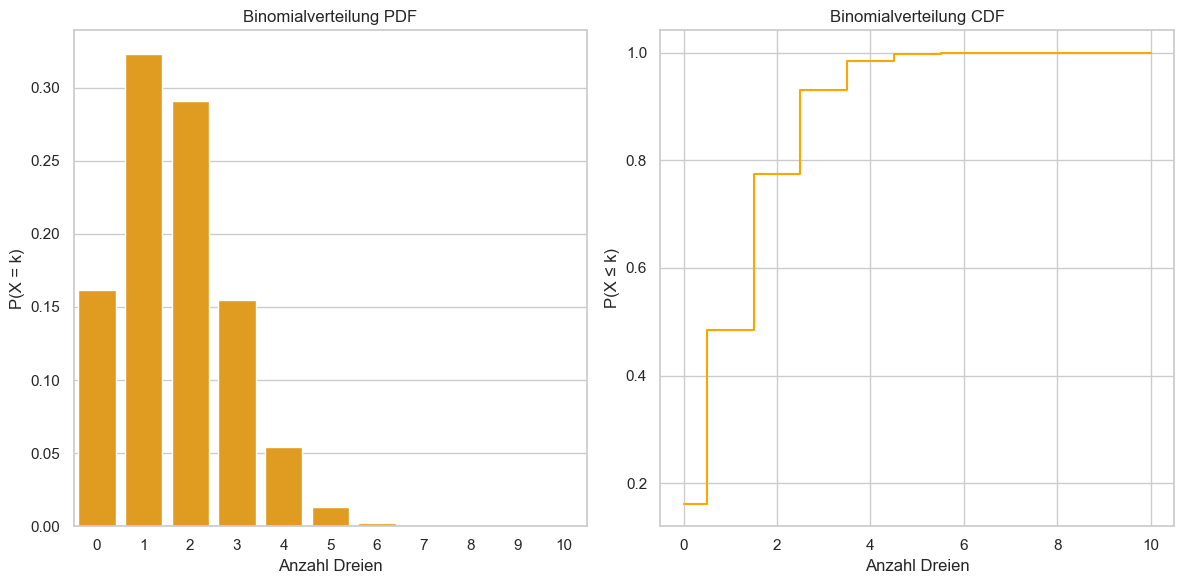

In [ ]:
import numpy as np
# Parameter
n = 10      # Anzahl Würfe
p = 1/6     # Wahrscheinlichkeit für die Zahl 3
k = np.arange(0, n+1)  # mögliche Anzahl Dreien

# PDF: Wahrscheinlichkeit genau k Dreien
pdf = binom.pmf(k, n, p)

# CDF: Wahrscheinlichkeit höchstens k Dreien
cdf = binom.cdf(k, n, p)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))

# PDF
plt.subplot(1,2,1)
sns.barplot(x=k, y=pdf, color="orange")
plt.title("Binomialverteilung PDF")
plt.xlabel("Anzahl Dreien")
plt.ylabel("P(X = k)")

# CDF
plt.subplot(1,2,2)
sns.lineplot(x=k, y=cdf, color="orange",drawstyle="steps-mid")
plt.title("Binomialverteilung CDF")
plt.xlabel("Anzahl Dreien")
plt.ylabel("P(X ≤ k)")

plt.tight_layout()
plt.show()
